<div style="background-color:#c3faf6; color:#222222; border:3px solid #bee5eb; padding:12px 14px; border-radius:10px; margin:10px 0;">

# How Facial Recognition Bias Compounds Across Race and Gender as Subjects Age


**CS109b Group #103**:Jenni Arakaki, Laine Roper, Arian Nzioka
**Project #18**: 

Project Proposal: https://drive.google.com/file/d/1yRPxpvg4jQc8gwzPgP_ptiSU6Qs4qmL1/view

## EXTRA RESULTS

In [1]:
!pip install kagglehub
# Standard library
import os
import gc
import time
import warnings

# Numerical computing and data processing
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import Counter
import zipfile

# external utilities
import kagglehub
import hashlib

# Visualization
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from torchvision import transforms
import torchvision.transforms as T

# UMAP
#import umap
from tqdm import tqdm
import umap
from umap import UMAP

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Suppress warnings
warnings.filterwarnings('ignore')

### Downloading/Accessing data:
1) Download data from https://www.kaggle.com/datasets/jangedoo/utkface-new.
2) kagglehub library downloads and stores data in `./cache` directory for reproducibility

In [3]:
path = kagglehub.dataset_download("jangedoo/utkface-new")
utk_path = next(Path(path).rglob("UTKFace"))

print("Path Exists  :", utk_path.exists())
print(f"Dataset downloaded to:", utk_path)

Path Exists  : True
Dataset downloaded to: /shared/home/lar160/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/UTKFace


In [4]:
# put image paths into Dataset, make all RGB, count how many
class FlatImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.files   = [f for f in self.img_dir.rglob("*")
                        if f.name.endswith(".jpg")
                        or f.name.endswith(".jpeg")
                        or f.name.endswith(".png")]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.files[idx].name

dataset = FlatImageDataset(utk_path)

size = 0
img_count = 0
for dirpath, dirnames, filenames in os.walk(utk_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        size += os.path.getsize(fp)
        img_count += 1

print(f"Number of images : {img_count}")
print(f"Size on disk   : {size / (1024**2):.2f} MB")

Number of images : 23708
Size on disk   : 114.43 MB


## PREPROCESSING, SKIP TO AUGMENTATION + REWEIGHTING STRATEGY 1

### Search for and Remove Duplicate Images

Here we load each image, convert its pixel data into a byte representation, and computes an MD5 hash that acts like a unique fingerprint for the image. We use the hashes to identify and remove duplicate images, keeping only the first occurrence of each. Other than this removal we are currently using the entire dataset.

### Labels:

The UTK dataset is a facial close-up collection of labeled images. Each image data features is embedded in the file name, formated like [age]_[gender]_[race]_[date&time].jpg

- `age` is an integer from `0`to `116`, indicating the age
- `gender` is either 0 `male` or 1 `female`
- `race` is an integer from 0 to 4, denoting `White`, `Black`, `Asian`, `Indian`, and `Others` (like `Hispanic`, `Latino`, `Middle Eastern`).
- `date&time` is in the format of `yyyymmddHHMMSSFFF`, showing the date and time an image was collected to UTKFace

In [5]:
CACHE_FILE = "nodup_dataset.pkl"

# ============================================================
# LOAD CLEANED DATASET IF IT EXISTS
# ============================================================
if os.path.exists(CACHE_FILE):

    print(f"Loading non-dup dataset from: {CACHE_FILE}")
    df = pd.read_pickle(CACHE_FILE)
    print(f"Loaded dataset size : {len(df)}")

else:

    print("No cached dataset found.")
    print("Hashing images...")

    def hash_image(img):
        """Generate MD5 hash from image pixels."""
        return hashlib.md5(np.array(img).tobytes()).hexdigest()

    # --- compute hashes directly from image files ---
    hashes = []
    images = []

    for p in dataset.files:
        img = Image.open(p).convert("RGB")
        images.append(img)
        hashes.append(hash_image(img))

    df = pd.DataFrame({
        "path": dataset.files,
        "image": images,
        "hash": hashes
    })

    # ============================================================
    # DUPLICATE ANALYSIS
    # ============================================================
    dup_mask = df.duplicated(subset='hash', keep=False)
    duplicates = df[dup_mask].copy()

    n_before = len(df)
    num_removed = df.duplicated(subset='hash', keep='first').sum()

    print(f"Total images before : {n_before}")
    print(f"Duplicate images found : {len(duplicates)}")
    print(f"Duplicate images removed : {num_removed}")

    # ============================================================
    # VISUALIZE DUPLICATES
    # ============================================================
    dup_groups = list(duplicates.groupby('hash'))

    if len(dup_groups) > 0:

        n_groups = min(3, len(dup_groups))
        cols = 4

        fig, axes = plt.subplots(
            n_groups,
            cols,
            figsize=(10, 3 * n_groups)
        )

        if n_groups == 1:
            axes = [axes]

        for row_i, (hash_val, group) in enumerate(dup_groups[:n_groups]):

            group = group.reset_index(drop=True)

            for col_i in range(cols):

                ax = axes[row_i][col_i] if n_groups > 1 else axes[col_i]

                if col_i < len(group):

                    r = group.iloc[col_i]

                    name = os.path.basename(str(r['path']))
                    short_name = (
                        name[:22] + "..."
                        if len(name) > 22 else name
                    )

                    ax.imshow(r['image'])
                    ax.set_title(short_name, fontsize=7)

                ax.axis('off')

        plt.suptitle("Duplicate Image Groups", fontsize=12)
        plt.tight_layout()
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        plt.show()

    # ============================================================
    # REMOVE DUPLICATES (keep one copy of each)
    # ============================================================
    df = df.drop_duplicates(
        subset='hash',
        keep='first'
    ).reset_index(drop=True)

    print("\nDuplicates Removed.")
    print(f"Non-duplicated dataset size : {len(df)}")

    # ============================================================
    # SAVE CLEANED DATASET
    # ============================================================
    df.to_pickle(CACHE_FILE)

    print(f"Saved non-dup dataset to: {CACHE_FILE}")

Loading non-dup dataset from: nodup_dataset.pkl
Loaded dataset size : 23318


In [6]:
# ============================================================
# ADD LABELS TO CLEANED DATAFRAME
# ============================================================

def parse_utk_filename(filename):
    parts = filename.split("_")

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
        return age, gender, race
    except:
        return None

# parse labels from filenames
labels = []

for p in df["path"]:
    parsed = parse_utk_filename(os.path.basename(str(p)))

    if parsed is None:
        labels.append((None, None, None))
    else:
        labels.append(parsed)

df[["age", "gender", "race"]] = pd.DataFrame(
    labels,
    index=df.index
)

# remove invalid rows if any
df = df.dropna(subset=["age", "gender", "race"]).reset_index(drop=True)

# optional: convert to int
df["age"] = df["age"].astype(int)
df["gender"] = df["gender"].astype(int)
df["race"] = df["race"].astype(int)

# ============================================================
# PYTORCH DATASET
# ============================================================

class DFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = row["image"]

        if self.transform:
            img = self.transform(img)

        return (
            img,
            torch.tensor(row["age"]),
            torch.tensor(row["gender"]),
            torch.tensor(row["race"])
        )

transform = transforms.Compose([
    transforms.ToTensor(),
])

clean_dataset = DFDataset(df, transform=transform)

print(f"Clean dataset size: {len(clean_dataset):,} images")

Clean dataset size: 23,315 images


In [7]:
SEED = 42

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # deterministic CUDA behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # stricter determinism
    torch.use_deterministic_algorithms(True)

set_seed(SEED)
    
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)
#reproducibility ^^^^^^^

labels = ["0_5",      # infants / toddlers
          "5_13",     # children
          "13_20",    # teens
          "21_40",
          "41_60",
          "61_80",
          "80_plus"
]

df["eval_age_bin"] = pd.cut(
    df["age"],
    bins = [0, 5, 13, 20, 40, 60, 80, 120],
    labels = labels,
    include_lowest=True
)

# simple stratification key
df["stratify_key"] = (
    df["race"].astype(str) + "_" +
    df["gender"].astype(str) + "_"
)

# remove very tiny groups if stratification breaks
valid_keys = df["stratify_key"].value_counts()
valid_keys = valid_keys[valid_keys >= 2].index
df_split = df[df["stratify_key"].isin(valid_keys)].copy()
df_split = df_split.sample(frac=1, random_state=SEED).reset_index(drop=True) #shuffles rows the same every 
                                                                            #time and cleans up index

train_df, temp_df = train_test_split(
    df_split,
    test_size=0.30,
    random_state=SEED,
    stratify=df_split["stratify_key"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["stratify_key"]
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 16320
Validation size: 3497
Test size: 3498


In [8]:
class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # already a PIL image
        image = row["image"]

        if self.transform:
            image = self.transform(image)

        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        race = str(row["race"])
        age_bin = str(row["eval_age_bin"])

        return image, age, gender, race, age_bin

In [9]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225] #normalize

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# dataloaders
train_dataset = UTKFaceDataset(train_df, transform=train_transform)
val_dataset = UTKFaceDataset(val_df, transform=val_transform)
test_dataset = UTKFaceDataset(test_df, transform=test_transform)

train_loader = DataLoader( #changed for seed
    train_dataset,
    batch_size=64,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g,
    num_workers=0
)
val_loader = DataLoader( #changed for seed
    val_dataset,
    batch_size=64,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=g,
    num_workers=0
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
    
class MultiTaskResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.age_head = nn.Linear(in_features, 1)
        self.gender_head = nn.Linear(in_features, 1)

    def forward(self, x, return_features=False):
        features = self.backbone(x)

        age_pred = self.age_head(features).squeeze(1)
        gender_logit = self.gender_head(features).squeeze(1)

        if return_features:
            return age_pred, gender_logit, features

        return age_pred, gender_logit
    
def extract_embeddings(model, loader, device):
    model.eval()

    embeddings = []
    age_preds = []
    gender_preds = []
    age_bins = []
    races = []
    genders = []

    with torch.no_grad():
        for images, ages, gender, race, age_bin in loader:
            images = images.to(device)

            age_pred, gender_logit, features = model(images, return_features=True)

            gender_pred = (torch.sigmoid(gender_logit) >= 0.5).float()

            embeddings.append(features.cpu())
            age_preds.append(age_pred.cpu())
            gender_preds.append(gender_pred.cpu())

            age_bins.extend(age_bin)
            races.extend(race)
            genders.extend(gender)

    return {
        "embeddings": torch.cat(embeddings),
        "age_pred": torch.cat(age_preds),
        "gender_pred": torch.cat(gender_preds),
        "age_bin": np.array(age_bins),
        "race": np.array(races),
        "gender": np.array(genders)
    }

def train_one_epoch(model, loader, optimizer, age_criterion, gender_criterion, device):
    model.train()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    for images, ages, genders, _, _ in tqdm(loader, desc="Training"):
        images = images.to(device)
        ages = ages.to(device)
        genders = genders.to(device)

        optimizer.zero_grad()

        age_pred, gender_logit = model(images)

        age_loss = age_criterion(age_pred, ages)
        gender_loss = gender_criterion(gender_logit, genders)

        loss = age_loss + gender_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_age_loss += age_loss.item() * images.size(0)
        total_gender_loss += gender_loss.item() * images.size(0)

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n
    }

def evaluate(model, loader, age_criterion, gender_criterion, device):
    model.eval()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    all_age_preds = []
    all_ages = []
    all_gender_preds_list = []
    all_genders = []

    with torch.no_grad():
        for images, ages, genders, _, _ in loader:
            images = images.to(device)
            ages = ages.to(device)
            genders = genders.to(device)

            age_pred, gender_logit = model(images)

            age_loss = age_criterion(age_pred, ages)
            gender_loss = gender_criterion(gender_logit, genders)
            loss = age_loss + gender_loss

            total_loss += loss.item() * images.size(0)
            total_age_loss += age_loss.item() * images.size(0)
            total_gender_loss += gender_loss.item() * images.size(0)

            gender_preds = (torch.sigmoid(gender_logit) >= 0.5).float()

            all_age_preds.append(age_pred.cpu())
            all_ages.append(ages.cpu())
            all_gender_preds_list.append(gender_preds.cpu())
            all_genders.append(genders.cpu())

    # safety check (prevents silent crashes)
    if len(all_gender_preds_list) == 0:
        raise RuntimeError("No validation predictions collected. Check DataLoader.")

    all_age_preds = torch.cat(all_age_preds)
    all_ages = torch.cat(all_ages)
    all_gender_preds = torch.cat(all_gender_preds_list)
    all_genders = torch.cat(all_genders)

    age_mae = torch.mean(torch.abs(all_age_preds - all_ages)).item()
    gender_acc = (all_gender_preds == all_genders).float().mean().item()

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "age_mae": age_mae,
        "gender_acc": gender_acc
    }
    
def compute_group_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / len(y_true)
    fpr = fp / (fp + tn + 1e-8)
    fnr = fn / (fn + tp + 1e-8)

    return acc, fpr, fnr

In [10]:
def to_matrix(metric_dict, row_name, col_name, value_key):

    rows = []

    for k, v in metric_dict.items():

        if not isinstance(k, tuple):
            k = (k,)

        rows.append((
            *k,
            v[value_key],
            v["count"]
        ))

    df = pd.DataFrame(
        rows,
        columns=[row_name, col_name, "value", "count"]
    )

    value_matrix = df.pivot(
        index=row_name,
        columns=col_name,
        values="value"
    )

    count_matrix = df.pivot(
        index=row_name,
        columns=col_name,
        values="count"
    )

    return value_matrix, count_matrix

Gender accuracy generally worse for asians and other, but especially poor for black labeled photos in the 80+ years old bin. The model also has a tough time predicting the genders of children aged 0-5, which makes sense as many people also struggle to tell the difference between genders of kids these ages. 

Older ages are generally harder for the model to accurately predict, this trend is clearly seen in the last figure. The other category intersected with 80+ years old has an especially high MAE.


## Augmentation + Reweighting Strategy 1

This reweighting method first groups each training sample by its intersection of race, gender, and age bin, then counts how frequently each group appears in the dataset. It assigns each sample a weight equal to the inverse of its group frequency, so rarer groups receive higher weights and common groups receive lower weights. 

In MS3, we used the WeightedRandomSampler uses these weights to sample training examples with replacement, meaning minority groups are drawn more often within each epoch. 

Here, instead of reweighting sampling probabilities, we tried to use frequencies to adjust augmentation strength during training. Samples from rare groups receive stronger augmentations (e.g., heavier color jitter, rotation, cropping), while common groups receive mild augmentation. All samples are still drawn normally from the dataset, but rare groups are made more diverse through stronger transformations.

This increases the effective variability of underrepresented groups without oversampling or duplication, reducing bias toward overrepresented demographics.

In [14]:
#UPSAMPLING RARE RACE AND GENDER COMBINATIONS
race = train_df["race"].astype(str).values
gender = train_df["gender"].astype(str).values
age_bin = train_df["eval_age_bin"].astype(str).values

groups = race + "_" + gender + "_" + age_bin

unique_groups, counts = np.unique(groups, return_counts=True)
group_freq = dict(zip(unique_groups, counts))

# define rarity threshold (tune this!)
RARE_THRESHOLD = np.percentile(counts, 25)  # bottom 25% as rare

rare_groups = {
    g for g, c in group_freq.items()
    if c <= RARE_THRESHOLD
}
 #edited for augmentation logic: rare group detection
class UTKFaceDataset(Dataset):
    def __init__(self, df, mild_transform=None, strong_transform=None, rare_groups=None):
        self.df = df.reset_index(drop=True)
        self.mild_transform = mild_transform
        self.strong_transform = strong_transform
        self.rare_groups = rare_groups if rare_groups is not None else set()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # load image
        img = Image.open(row["path"]).convert("RGB")

        # build group key
        race = str(row["race"])
        gender = str(row["gender"])
        age_bin = str(row["eval_age_bin"])
        group = f"{race}_{gender}_{age_bin}"

        # choose augmentation strength
        if group in self.rare_groups:
            if self.strong_transform:
                img = self.strong_transform(img)
        else:
            if self.mild_transform:
                img = self.mild_transform(img)

        # labels (match your original format)
        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        return img, age, gender, race, age_bin

#for well represented samples
mild_aug = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

#for underrepresented samples
strong_aug = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    T.RandomRotation(15),
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.ToTensor(),
])

# dataloaders
train_dataset = UTKFaceDataset(
    train_df,
    mild_transform=mild_aug,
    strong_transform=strong_aug,
    rare_groups=rare_groups
)
val_dataset = UTKFaceDataset(
    val_df,
    mild_transform=val_transform,
    strong_transform=None,
    rare_groups=set()  # no augmentation logic in val
)

test_dataset = UTKFaceDataset(
    test_df,
    mild_transform=test_transform,
    strong_transform=None,
    rare_groups=set() # no augmentation logic in val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True, 
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=g
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

resnet_model = MultiTaskResNet().to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)

num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": []
}

best_val_mae = float("inf")
best_gender_acc = 0.0

BEST_MODEL_PATH = "best_resnet_reweighted_hard.pt"

# =========================
# LOAD BEST MODEL IF EXISTS
# =========================
if os.path.exists(BEST_MODEL_PATH):
    print("Loading BEST model...")

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    resnet_model.load_state_dict(checkpoint["model_state"])

    history = checkpoint.get("history", {
        "train_loss": [],
        "val_loss": [],
        "val_age_mae": [],
        "val_gender_acc": []
    })

    best_val_loss = checkpoint.get("best_val_loss", float("inf"))

    print("Loaded BEST model")

else:
    print("No checkpoint found. Training from scratch.")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_age_mae": [],
        "val_gender_acc": []
    }

    best_val_loss = float("inf")

    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
    
        # ---- train ----
        train_metrics = train_one_epoch(
            resnet_model, train_loader, optimizer,
            age_criterion, gender_criterion, device
        )
    
        # ---- validate ----
        val_metrics = evaluate(
            resnet_model, val_loader,
            age_criterion, gender_criterion, device
        )
    
        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_age_mae"].append(val_metrics["age_mae"])
        history["val_gender_acc"].append(val_metrics["gender_acc"])
    
        print(f"Train Loss: {train_metrics['loss']:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Age MAE: {val_metrics['age_mae']:.2f} | "
              f"Gender Acc: {val_metrics['gender_acc']:.3f}")
    
        # ---- save best model (by val loss) ----
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
    
            torch.save({
                "model_state": resnet_model.state_dict(),
                "history": history,
                "best_val_loss": best_val_loss,
                "num_epochs": num_epochs,
                "seed": SEED
            }, BEST_MODEL_PATH)
    
            print("Saved new best model (lowest val loss)")

            end_time = time.time()
            print(f"\nTraining time: {(end_time - start_time)/60:.2f} minutes")

Loading BEST model...
Loaded BEST model


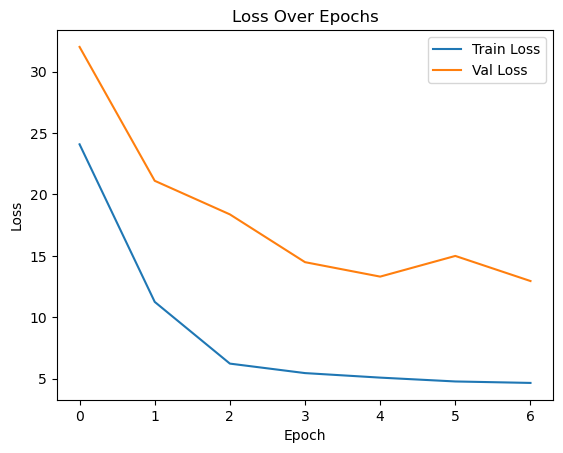

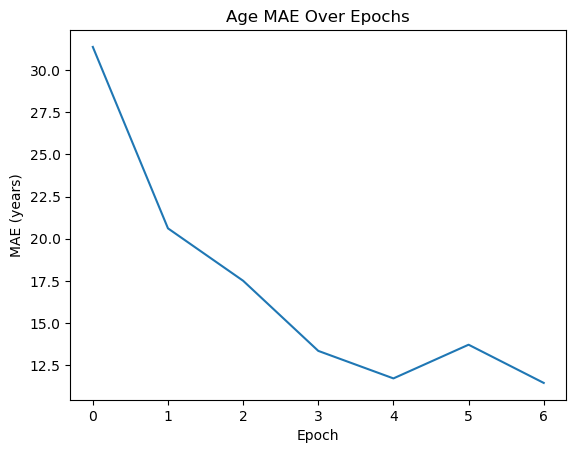

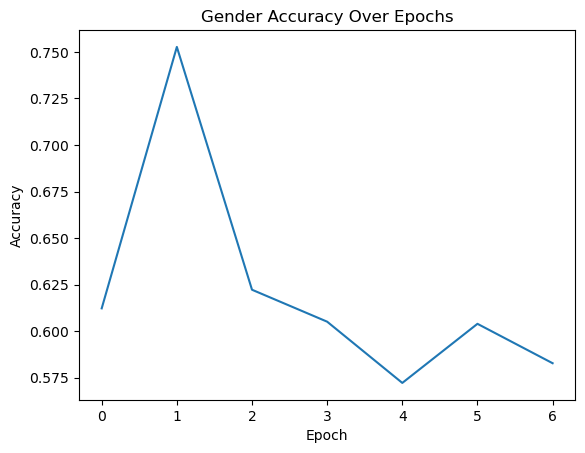

In [15]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"], label="Val Gender Acc")
plt.title("Gender Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

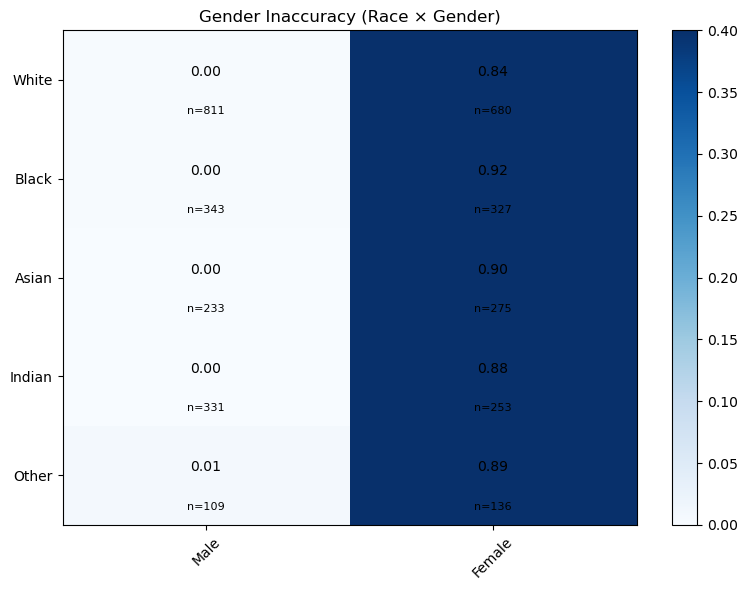

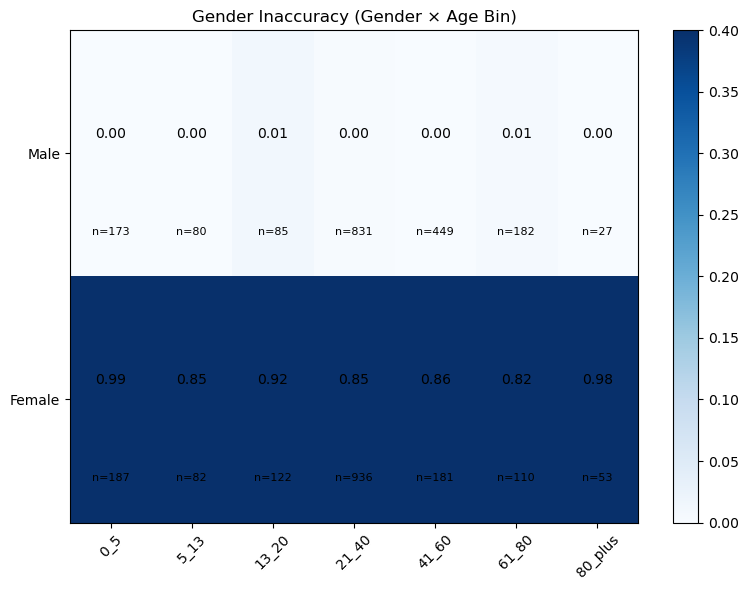

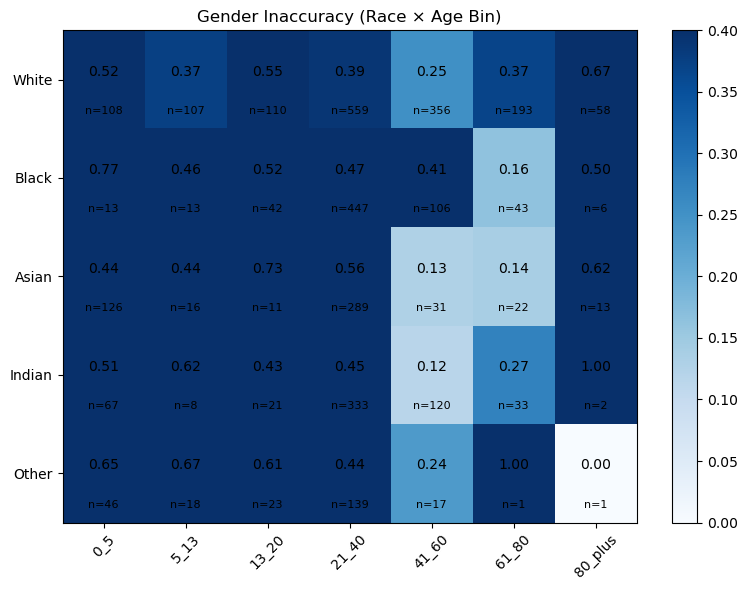

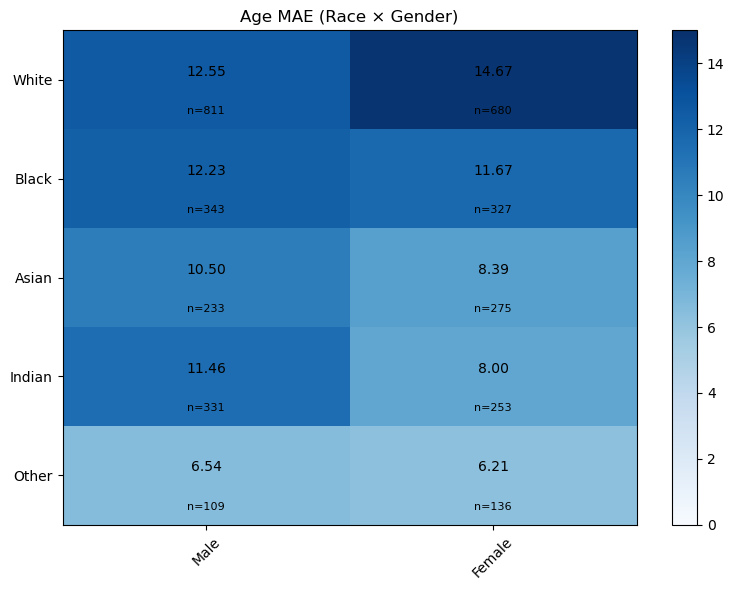

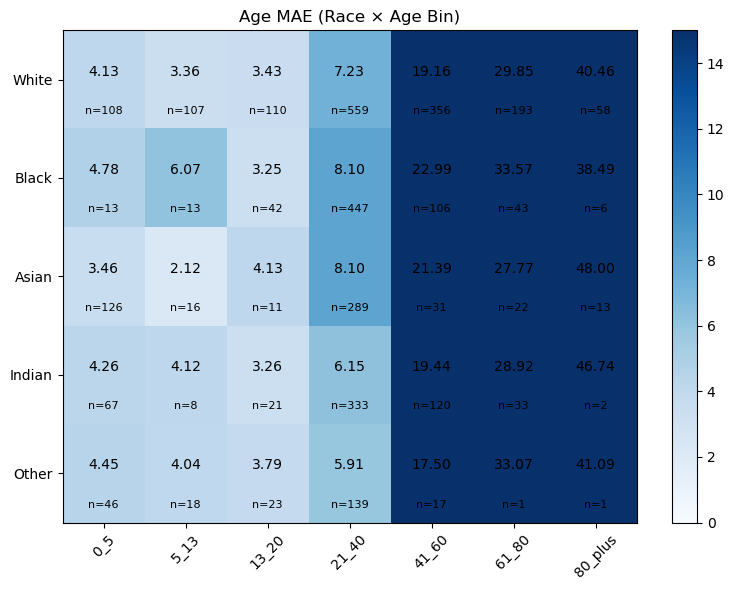

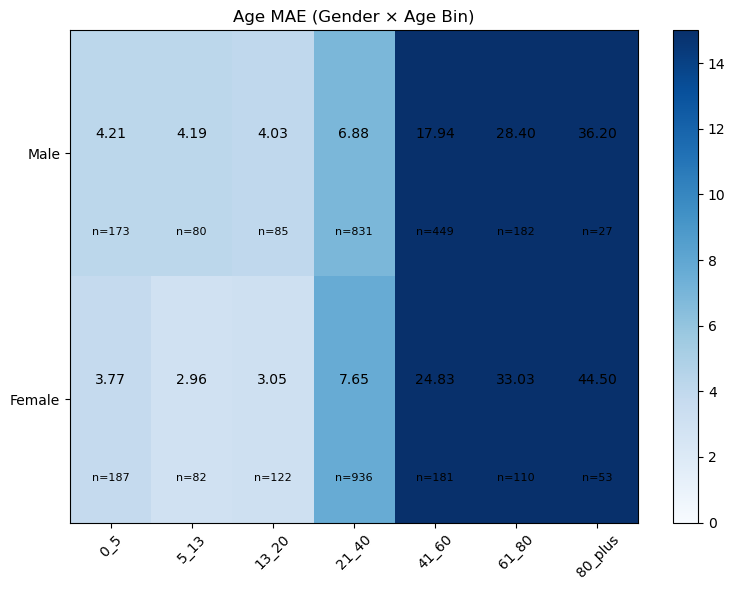

In [19]:
gender_map = {
    0: "Male",
    1: "Female"
}

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}


# =========================================================
# GET TEST PREDICTIONS
# =========================================================

def get_test_predictions(model, loader, device):

    model.eval()
    results = []

    with torch.no_grad():

        for images, ages, genders, races, age_bins in loader:

            images = images.to(device)

            age_pred, gender_logit = model(images)

            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()

            for i in range(len(images)):

                g = int(genders[i].item())
                p = int(gender_pred[i].item())

                r = int(
                    races[i].item()
                    if hasattr(races[i], "item")
                    else races[i]
                )

                results.append({

                    "true_age":
                        ages[i].item(),

                    "pred_age":
                        age_pred[i].item(),

                    "age_error":
                        age_pred[i].item() - ages[i].item(),

                    "true_gender":
                        gender_map[g],

                    "pred_gender":
                        gender_map[p],

                    "gender_correct":
                        int(p == g),

                    "race":
                        race_map[r],

                    "age_bin":
                        str(age_bins[i])
                })

    return pd.DataFrame(results)


# =========================================================
# TEST RESULTS
# =========================================================

test_results_reweighted = get_test_predictions(
    resnet_model,
    test_loader,
    device
)


# =========================================================
# COMPUTE GROUP METRICS
# =========================================================

def compute_group_metrics(df, group_cols):

    grouped = df.groupby(group_cols)

    out = {}

    for name, sub in grouped:

        out[name] = {

            "gender_acc":
                sub["gender_correct"].mean(),

            "age_mae":
                np.abs(sub["age_error"]).mean(),

            "count":
                len(sub)
        }

    return out

# =========================================================
# REORDER MATRICES
# =========================================================

def reorder_matrix(matrix, row_order=None, col_order=None):

    if row_order is not None:
        matrix = matrix.reindex(row_order)

    if col_order is not None:
        matrix = matrix.reindex(columns=col_order)

    return matrix


# =========================================================
# HEATMAP PLOTTING
# =========================================================

def plot_heatmap(
    matrix,
    counts,
    title,
    cmap="Blues",
    vmin=None,
    vmax=None
):

    plt.figure(figsize=(8, 6))

    if vmin is None:
        vmin = np.nanmin(matrix.values)

    if vmax is None:
        vmax = np.nanmax(matrix.values)

    im = plt.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.title(title)

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45
    )

    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    # annotations
    for i in range(matrix.shape[0]):

        for j in range(matrix.shape[1]):

            val = matrix.iloc[i, j]
            cnt = counts.iloc[i, j]

            if not np.isnan(val):

                # main metric
                plt.text(
                    j,
                    i - 0.08,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="black"
                )

                # frequency count near bottom
                plt.text(
                    j,
                    i + 0.32,
                    f"n={int(cnt)}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

    plt.colorbar(im)

    plt.tight_layout()
    plt.show()


# =========================================================
# COMPUTE INTERSECTIONAL GROUPS
# =========================================================

race_gender = compute_group_metrics(
    test_results_reweighted,
    ["race", "true_gender"]
)

race_age = compute_group_metrics(
    test_results_reweighted,
    ["race", "age_bin"]
)

gender_age = compute_group_metrics(
    test_results_reweighted,
    ["true_gender", "age_bin"]
)


# =========================================================
# BUILD MATRICES
# =========================================================

# ---------- Race × Gender ----------

rg_acc, rg_counts = to_matrix(
    race_gender,
    "race",
    "gender",
    "gender_acc"
)

rg_mae, _ = to_matrix(
    race_gender,
    "race",
    "gender",
    "age_mae"
)

# ---------- Race × Age ----------

ra_acc, ra_counts = to_matrix(
    race_age,
    "race",
    "age_bin",
    "gender_acc"
)

ra_mae, _ = to_matrix(
    race_age,
    "race",
    "age_bin",
    "age_mae"
)

# ---------- Gender × Age ----------

ga_acc, ga_counts = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "gender_acc"
)

ga_mae, _ = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "age_mae"
)


# =========================================================
# INACCURACY MATRICES
# =========================================================

rg_inacc = 1 - rg_acc
ra_inacc = 1 - ra_acc
ga_inacc = 1 - ga_acc


# =========================================================
# REORDER MATRICES
# =========================================================
race_order = ["White", "Black", "Asian", "Indian", "Other"]
gender_order = ["Male", "Female"]
age_order = ["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"]

rg_acc = reorder_matrix(rg_acc, race_order, gender_order)
rg_mae = reorder_matrix(rg_mae, race_order, gender_order)
rg_inacc = reorder_matrix(rg_inacc, race_order, gender_order)
rg_counts = reorder_matrix(rg_counts, race_order, gender_order)

ra_acc = reorder_matrix(ra_acc, race_order, age_order)
ra_mae = reorder_matrix(ra_mae, race_order, age_order)
ra_inacc = reorder_matrix(ra_inacc, race_order, age_order)
ra_counts = reorder_matrix(ra_counts, race_order, age_order)

ga_acc = reorder_matrix(ga_acc, gender_order, age_order)
ga_mae = reorder_matrix(ga_mae, gender_order, age_order)
ga_inacc = reorder_matrix(ga_inacc, gender_order, age_order)
ga_counts = reorder_matrix(ga_counts, gender_order, age_order)


# =========================================================
# PLOTS
# =========================================================

INACC_VMIN, INACC_VMAX = 0.0, 0.4
MAE_VMIN, MAE_VMAX = 0.0, 15.0


# ---------- Gender Inaccuracy ----------

plot_heatmap(
    rg_inacc,
    rg_counts,
    "Gender Inaccuracy (Race × Gender)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ga_inacc,
    ga_counts,
    "Gender Inaccuracy (Gender × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ra_inacc,
    ra_counts,
    "Gender Inaccuracy (Race × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)


# ---------- Age MAE ----------

plot_heatmap(
    rg_mae,
    rg_counts,
    "Age MAE (Race × Gender)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ra_mae,
    ra_counts,
    "Age MAE (Race × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ga_mae,
    ga_counts,
    "Age MAE (Gender × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

This approach clearly doesn’t work well. It changes both how often different groups appear and how they look in the training data at the same time. Rare groups get seen more and also receive stronger augmentation, which probably distort important visual cues for age and gender prediction. Instead of reducing bias, this made performance gaps worse by increasing noise and inconsistency.

## Augmentation + Reweighting Strategy 2

This version replaces hard upsampling and “rare-group” rules with a probabilistic strategy, where each sample has a probability of receiving strong augmentation based on the inverse of group frequency.

In [21]:
#UPSAMPLING RARE RACE AND GENDER COMBINATIONS
race = train_df["race"].astype(str).values
gender = train_df["gender"].astype(str).values
age_bin = train_df["eval_age_bin"].astype(str).values

groups = race + "_" + gender + "_" + age_bin

unique_groups, counts = np.unique(groups, return_counts=True)
group_freq = dict(zip(unique_groups, counts))

# define rarity threshold (tune this!)
RARE_THRESHOLD = np.percentile(counts, 25)  # bottom 25% as rare

rare_groups = {
    g for g, c in group_freq.items()
    if c <= RARE_THRESHOLD
}
 #edited for augmentation logic: rare group detection
class UTKFaceDataset(Dataset):
    def __init__(self, df, mild_transform=None, strong_transform=None):
        self.df = df.reset_index(drop=True)

        self.mild_transform = mild_transform
        self.strong_transform = strong_transform

        # compute group frequencies
        groups = (
            df["race"].astype(str) + "_" +
            df["gender"].astype(str) + "_" +
            df["eval_age_bin"].astype(str)
        )

        group_counts = groups.value_counts().to_dict()

        # inverse frequency weights -> probability
        max_count = max(group_counts.values())

        self.p_strong = {
            g: (max_count / c) for g, c in group_counts.items()
        }

        # normalize to [0,1]
        max_p = max(self.p_strong.values())
        self.p_strong = {g: v / max_p for g, v in self.p_strong.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # load image
        img = Image.open(row["path"]).convert("RGB")

        # build group key
        race = str(row["race"])
        gender = str(row["gender"])
        age_bin = str(row["eval_age_bin"])
        group = f"{race}_{gender}_{age_bin}"

        # get probability of strong augmentation
        p_strong = self.p_strong.get(group, 0.0)

        # stochastic augmentation choice
        if self.strong_transform and random.random() < p_strong:
            img = self.strong_transform(img)
        elif self.mild_transform:
            img = self.mild_transform(img)

        # labels
        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        return img, age, gender, race, age_bin
        
#for well represented samples
mild_aug = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

#for underrepresented samples
strong_aug = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    T.RandomRotation(15),
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.ToTensor(),
])

# dataloaders
train_dataset = UTKFaceDataset(
    train_df,
    mild_transform=mild_aug,
    strong_transform=strong_aug
)
val_dataset = UTKFaceDataset(
    val_df,
    mild_transform=val_transform,
    strong_transform=None
)

test_dataset = UTKFaceDataset(
    test_df,
    mild_transform=test_transform,
    strong_transform=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True, 
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=g
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

resnet_model = MultiTaskResNet().to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)

num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": []
}

best_val_mae = float("inf")
best_gender_acc = 0.0

BEST_MODEL_PATH = "best_resnet_reweighted_soft.pt"

# =========================
# LOAD BEST MODEL IF EXISTS
# =========================
if os.path.exists(BEST_MODEL_PATH):
    print("Loading BEST model...")

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    resnet_model.load_state_dict(checkpoint["model_state"])

    history = checkpoint.get("history", {
        "train_loss": [],
        "val_loss": [],
        "val_age_mae": [],
        "val_gender_acc": []
    })

    best_val_loss = checkpoint.get("best_val_loss", float("inf"))

    print("Loaded BEST model")

else:
    print("No checkpoint found. Training from scratch.")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_age_mae": [],
        "val_gender_acc": []
    }

    best_val_loss = float("inf")

    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
    
        # ---- train ----
        train_metrics = train_one_epoch(
            resnet_model, train_loader, optimizer,
            age_criterion, gender_criterion, device
        )
    
        # ---- validate ----
        val_metrics = evaluate(
            resnet_model, val_loader,
            age_criterion, gender_criterion, device
        )
    
        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_age_mae"].append(val_metrics["age_mae"])
        history["val_gender_acc"].append(val_metrics["gender_acc"])
    
        print(f"Train Loss: {train_metrics['loss']:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Age MAE: {val_metrics['age_mae']:.2f} | "
              f"Gender Acc: {val_metrics['gender_acc']:.3f}")
    
        # ---- save best model (by val loss) ----
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
    
            torch.save({
                "model_state": resnet_model.state_dict(),
                "history": history,
                "best_val_loss": best_val_loss,
                "num_epochs": num_epochs,
                "seed": SEED
            }, BEST_MODEL_PATH)
    
            print("Saved new best model (lowest val loss)")
    
    end_time = time.time()
    print(f"\nTraining time: {(end_time - start_time)/60:.2f} minutes")

Loading BEST model...
Loaded BEST model


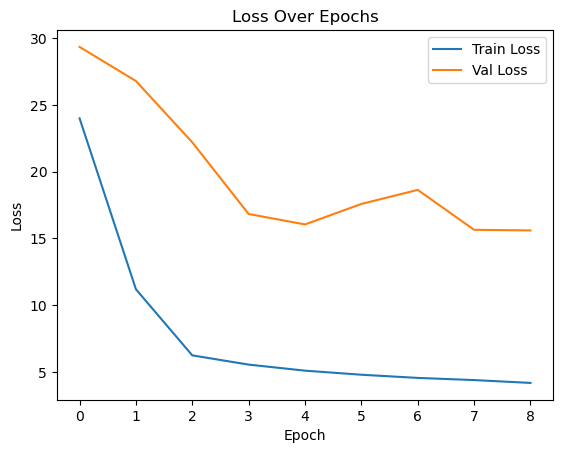

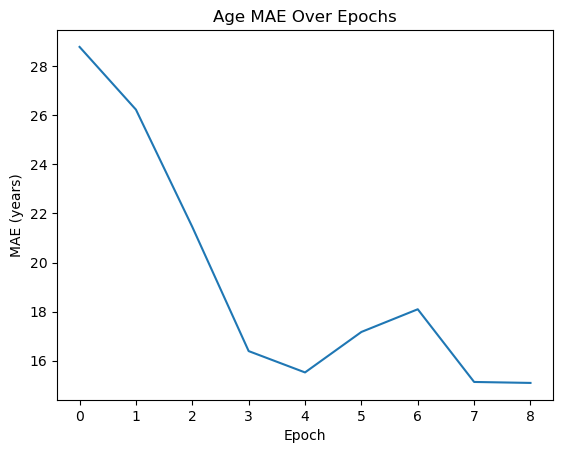

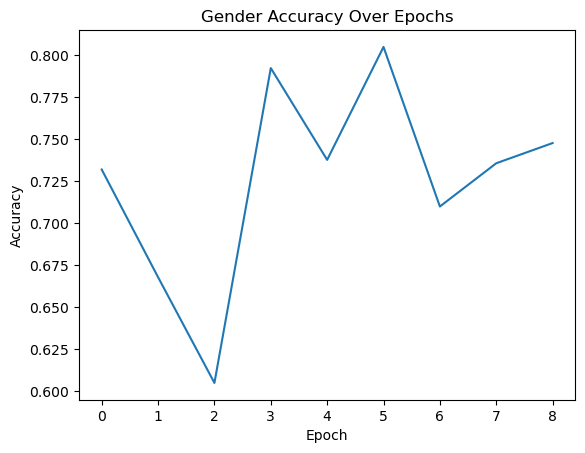

In [22]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"], label="Val Gender Acc")
plt.title("Gender Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

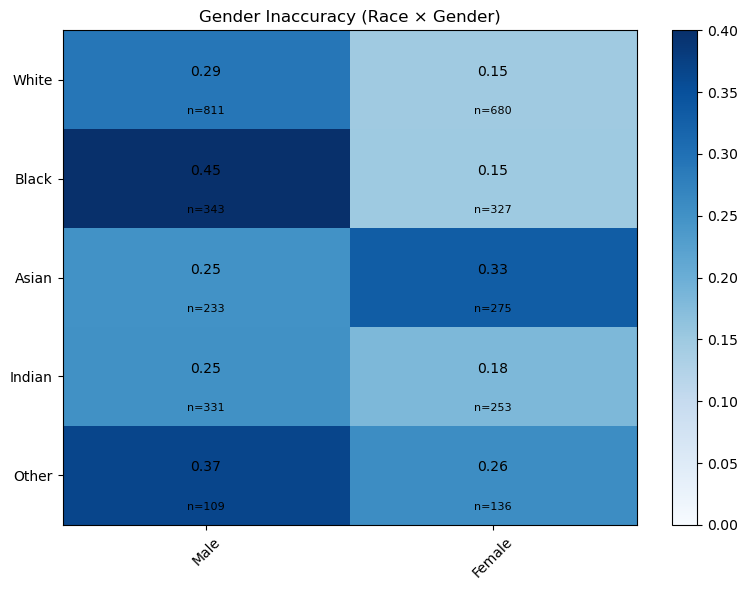

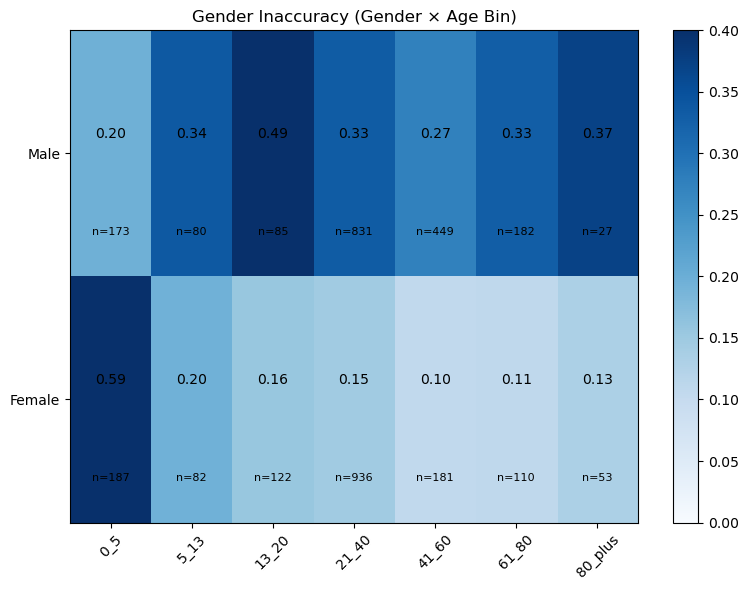

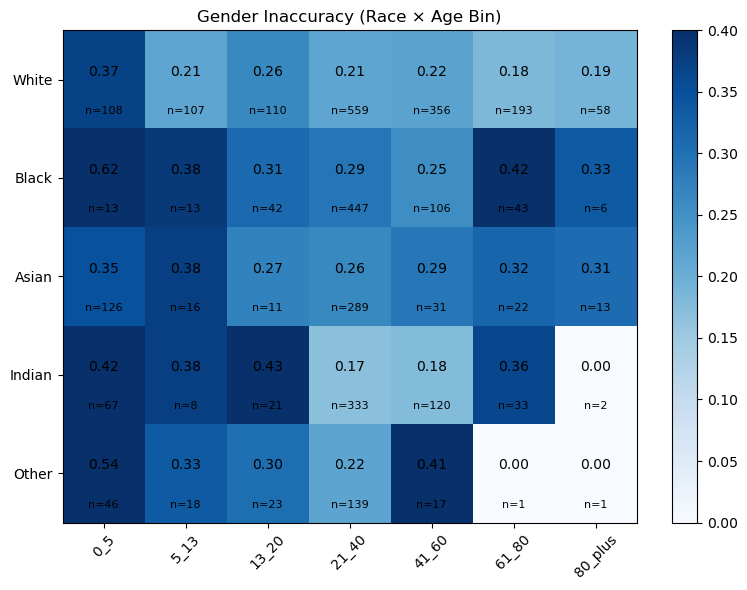

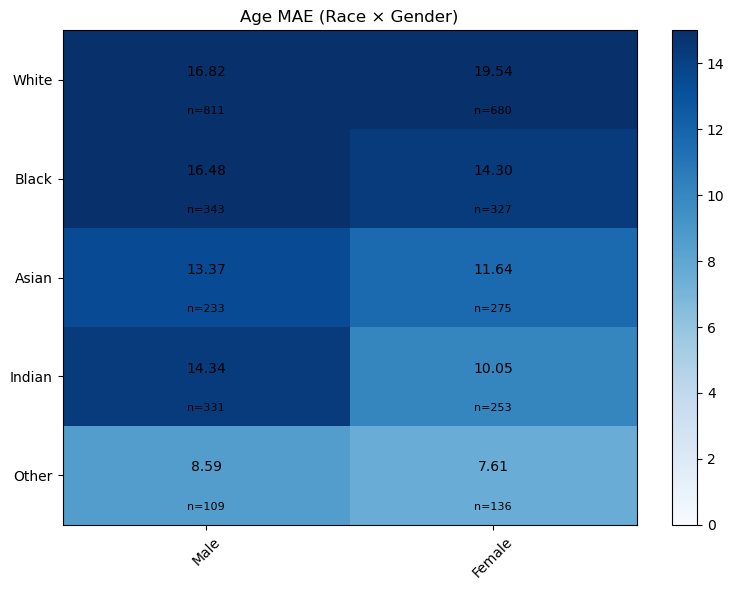

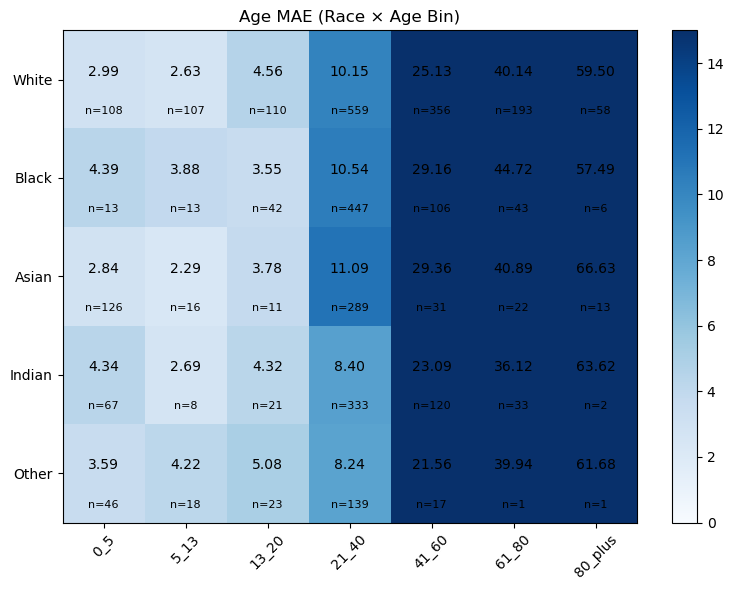

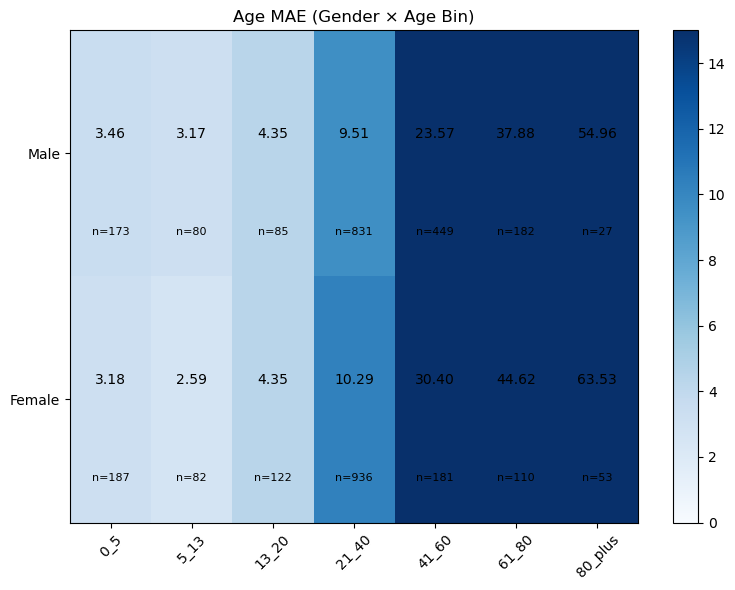

In [23]:
gender_map = {
    0: "Male",
    1: "Female"
}

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}


# =========================================================
# GET TEST PREDICTIONS
# =========================================================

def get_test_predictions(model, loader, device):

    model.eval()
    results = []

    with torch.no_grad():

        for images, ages, genders, races, age_bins in loader:

            images = images.to(device)

            age_pred, gender_logit = model(images)

            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()

            for i in range(len(images)):

                g = int(genders[i].item())
                p = int(gender_pred[i].item())

                r = int(
                    races[i].item()
                    if hasattr(races[i], "item")
                    else races[i]
                )

                results.append({

                    "true_age":
                        ages[i].item(),

                    "pred_age":
                        age_pred[i].item(),

                    "age_error":
                        age_pred[i].item() - ages[i].item(),

                    "true_gender":
                        gender_map[g],

                    "pred_gender":
                        gender_map[p],

                    "gender_correct":
                        int(p == g),

                    "race":
                        race_map[r],

                    "age_bin":
                        str(age_bins[i])
                })

    return pd.DataFrame(results)


# =========================================================
# TEST RESULTS
# =========================================================

test_results_reweighted = get_test_predictions(
    resnet_model,
    test_loader,
    device
)


# =========================================================
# COMPUTE GROUP METRICS
# =========================================================

def compute_group_metrics(df, group_cols):

    grouped = df.groupby(group_cols)

    out = {}

    for name, sub in grouped:

        out[name] = {

            "gender_acc":
                sub["gender_correct"].mean(),

            "age_mae":
                np.abs(sub["age_error"]).mean(),

            "count":
                len(sub)
        }

    return out

# =========================================================
# REORDER MATRICES
# =========================================================

def reorder_matrix(matrix, row_order=None, col_order=None):

    if row_order is not None:
        matrix = matrix.reindex(row_order)

    if col_order is not None:
        matrix = matrix.reindex(columns=col_order)

    return matrix


# =========================================================
# HEATMAP PLOTTING
# =========================================================

def plot_heatmap(
    matrix,
    counts,
    title,
    cmap="Blues",
    vmin=None,
    vmax=None
):

    plt.figure(figsize=(8, 6))

    if vmin is None:
        vmin = np.nanmin(matrix.values)

    if vmax is None:
        vmax = np.nanmax(matrix.values)

    im = plt.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.title(title)

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45
    )

    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    # annotations
    for i in range(matrix.shape[0]):

        for j in range(matrix.shape[1]):

            val = matrix.iloc[i, j]
            cnt = counts.iloc[i, j]

            if not np.isnan(val):

                # main metric
                plt.text(
                    j,
                    i - 0.08,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="black"
                )

                # frequency count near bottom
                plt.text(
                    j,
                    i + 0.32,
                    f"n={int(cnt)}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

    plt.colorbar(im)

    plt.tight_layout()
    plt.show()


# =========================================================
# COMPUTE INTERSECTIONAL GROUPS
# =========================================================

race_gender = compute_group_metrics(
    test_results_reweighted,
    ["race", "true_gender"]
)

race_age = compute_group_metrics(
    test_results_reweighted,
    ["race", "age_bin"]
)

gender_age = compute_group_metrics(
    test_results_reweighted,
    ["true_gender", "age_bin"]
)


# =========================================================
# BUILD MATRICES
# =========================================================

# ---------- Race × Gender ----------

rg_acc, rg_counts = to_matrix(
    race_gender,
    "race",
    "gender",
    "gender_acc"
)

rg_mae, _ = to_matrix(
    race_gender,
    "race",
    "gender",
    "age_mae"
)

# ---------- Race × Age ----------

ra_acc, ra_counts = to_matrix(
    race_age,
    "race",
    "age_bin",
    "gender_acc"
)

ra_mae, _ = to_matrix(
    race_age,
    "race",
    "age_bin",
    "age_mae"
)

# ---------- Gender × Age ----------

ga_acc, ga_counts = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "gender_acc"
)

ga_mae, _ = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "age_mae"
)


# =========================================================
# INACCURACY MATRICES
# =========================================================

rg_inacc = 1 - rg_acc
ra_inacc = 1 - ra_acc
ga_inacc = 1 - ga_acc


# =========================================================
# REORDER MATRICES
# =========================================================

rg_acc = reorder_matrix(rg_acc, race_order, gender_order)
rg_mae = reorder_matrix(rg_mae, race_order, gender_order)
rg_inacc = reorder_matrix(rg_inacc, race_order, gender_order)
rg_counts = reorder_matrix(rg_counts, race_order, gender_order)

ra_acc = reorder_matrix(ra_acc, race_order, age_order)
ra_mae = reorder_matrix(ra_mae, race_order, age_order)
ra_inacc = reorder_matrix(ra_inacc, race_order, age_order)
ra_counts = reorder_matrix(ra_counts, race_order, age_order)

ga_acc = reorder_matrix(ga_acc, gender_order, age_order)
ga_mae = reorder_matrix(ga_mae, gender_order, age_order)
ga_inacc = reorder_matrix(ga_inacc, gender_order, age_order)
ga_counts = reorder_matrix(ga_counts, gender_order, age_order)


# =========================================================
# PLOTS
# =========================================================

INACC_VMIN, INACC_VMAX = 0.0, 0.4
MAE_VMIN, MAE_VMAX = 0.0, 15.0


# ---------- Gender Inaccuracy ----------

plot_heatmap(
    rg_inacc,
    rg_counts,
    "Gender Inaccuracy (Race × Gender)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ga_inacc,
    ga_counts,
    "Gender Inaccuracy (Gender × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ra_inacc,
    ra_counts,
    "Gender Inaccuracy (Race × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)


# ---------- Age MAE ----------

plot_heatmap(
    rg_mae,
    rg_counts,
    "Age MAE (Race × Gender)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ra_mae,
    ra_counts,
    "Age MAE (Race × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ga_mae,
    ga_counts,
    "Age MAE (Gender × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

It still doesn’t work well because this strategy still pairs group identity with different augmentation distributions, which changes the input distribution per subgroup and probably amplifies bias instead of reduces.